In [7]:
# 1. Import Dependencies
import pandas as pd
import numpy as np
import random
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split
import matplotlib.pyplot as plt

In [9]:
# 2. Data Loading and Preprocessing
df = pd.read_csv("extracted_columns.csv")

# Prepare features and target
X = df[['PSS-1', 'PSS-2', 'PSS-3', 'PSS-4', 'PSS-5', 'PSS-6', 'PSS-7',
        'PSS-8', 'PSS-9', 'PSS-10', 'PSS-11', 'PSS-12', 'PSS-13', 'PSS-14']]
df['PSS_total'] = X.sum(axis=1)
y = df['PSS_total']


In [ ]:
# Train-test split (80/20) hold-out validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)



In [11]:
# 4. Random Forest Implementation
rfr_param_bounds = {
    'n_estimators': [50, 200],
    'max_depth': [None, 5, 10, 20, 50],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5]
}

def create_rfr_individual():
    return {
        'n_estimators': random.randint(rfr_param_bounds['n_estimators'][0], rfr_param_bounds['n_estimators'][1]),
        'max_depth': random.choice(rfr_param_bounds['max_depth']),
        'min_samples_split': random.randint(rfr_param_bounds['min_samples_split'][0], rfr_param_bounds['min_samples_split'][1]),
        'min_samples_leaf': random.randint(rfr_param_bounds['min_samples_leaf'][0], rfr_param_bounds['min_samples_leaf'][1])
    }
def mutate_rfr(individual, mutation_rate=0.1):
    if random.random() < mutation_rate:
        individual['n_estimators'] = int(np.clip(individual['n_estimators'] + random.randint(-10, 10), rfr_param_bounds['n_estimators'][0], rfr_param_bounds['n_estimators'][1]))
    if random.random() < mutation_rate:
        choices = [d for d in rfr_param_bounds['max_depth'] if d != individual['max_depth']]
        if choices:
            individual['max_depth'] = random.choice(choices)
    if random.random() < mutation_rate:
        individual['min_samples_split'] = int(np.clip(individual['min_samples_split'] + random.randint(-1, 1), rfr_param_bounds['min_samples_split'][0], rfr_param_bounds['min_samples_split'][1]))
    if random.random() < mutation_rate:
        individual['min_samples_leaf'] = int(np.clip(individual['min_samples_leaf'] + random.randint(-1, 1), rfr_param_bounds['min_samples_leaf'][0], rfr_param_bounds['min_samples_leaf'][1]))
    return individual

def fitness_rfr_kfold(individual, X_train, y_train, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmse_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = make_pipeline(
            StandardScaler(),
            RandomForestRegressor(
                n_estimators=individual['n_estimators'],
                max_depth=individual['max_depth'],
                min_samples_split=individual['min_samples_split'],
                min_samples_leaf=individual['min_samples_leaf'],
                random_state=42
            )
        )
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val_fold)
        rmse_scores.append(np.sqrt(mean_squared_error(y_val_fold, preds)))
    return -np.mean(rmse_scores)

def genetic_algorithm_rfr_kfold(X_train, y_train, generations=10, population_size=20, k=5):
    population = [create_rfr_individual() for _ in range(population_size)]
    for individual in population:
        individual['fitness'] = fitness_rfr_kfold(individual, X_train, y_train, k=k)
    for gen in range(generations):
        new_population = []
        while len(new_population) < population_size:
            parent1 = max(random.sample(population, 3), key=lambda ind: ind['fitness'])
            parent2 = max(random.sample(population, 3), key=lambda ind: ind['fitness'])
            child = {}
            for key in parent1.keys():
                if key != 'fitness':
                    child[key] = parent1[key] if random.random() > 0.5 else parent2[key]
            child = mutate_rfr(child)
            child['fitness'] = fitness_rfr_kfold(child, X_train, y_train, k=k)
            new_population.append(child)
        population = new_population
        best = max(population, key=lambda x: x['fitness'])
        print(f"Generation {gen+1}, Best RMSE: {-best['fitness']:.4f}, Params: {best}")
    best_individual = max(population, key=lambda x: x['fitness'])
    return best_individual


In [14]:
# New function to run multiple GA runs and aggregate results
def multiple_ga_runs_rfr(X_train, y_train, runs=30):
    results = []
    for run in range(runs):
        print(f"\n=== GA Run {run+1}/{runs} ===")
        seed = 42 + run
        random.seed(seed)
        np.random.seed(seed)
        best_params = genetic_algorithm_rfr_kfold(X_train, y_train)
        model = make_pipeline(
            StandardScaler(),
            RandomForestRegressor(
                n_estimators=best_params['n_estimators'],
                max_depth=best_params['max_depth'],
                min_samples_split=best_params['min_samples_split'],
                min_samples_leaf=best_params['min_samples_leaf'],
                random_state=42
            )
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_train)
        rmse = np.sqrt(mean_squared_error(y_train, preds))
        mae = mean_absolute_error(y_train, preds)
        r2 = r2_score(y_train, preds)
        results.append({
            'Run': run+1,
            'Seed': seed,
            'n_estimators': best_params['n_estimators'],
            'max_depth': best_params['max_depth'],
            'min_samples_split': best_params['min_samples_split'],
            'min_samples_leaf': best_params['min_samples_leaf'],
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        })
        print(f"Run {run+1} Metrics -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")
    rmse_vals = [r['RMSE'] for r in results]
    mae_vals = [r['MAE'] for r in results]
    r2_vals = [r['R2'] for r in results]
    print("\n=== Final 30-Run Summary ===")
    print(f"Average RMSE: {np.mean(rmse_vals):.4f} ± {np.std(rmse_vals):.4f}")
    print(f"Average MAE: {np.mean(mae_vals):.4f} ± {np.std(mae_vals):.4f}")
    print(f"Average R^2: {np.mean(r2_vals):.4f} ± {np.std(r2_vals):.4f}")
    results_df = pd.DataFrame(results)
    results_df.to_csv("GA_RFR_30_Run_Results.csv", index=False)
    plt.figure(figsize=(12,6))
    plt.subplot(1, 3, 1)
    plt.boxplot(rmse_vals)
    plt.title("RMSE Distribution")
    plt.ylabel("RMSE")
    plt.subplot(1, 3, 2)
    plt.boxplot(mae_vals)
    plt.title("MAE Distribution")
    plt.ylabel("MAE")
    plt.subplot(1, 3, 3)
    plt.boxplot(r2_vals)
    plt.title("R^2 Distribution")
    plt.ylabel("R^2")
    plt.suptitle("GA-Optimized RFR Performance over Multiple Runs")
    plt.tight_layout()
    plt.show()
    return results_df


=== GA Run 1/30 ===
Generation 1, Best RMSE: 2.1024, Params: {'n_estimators': 164, 'max_depth': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'fitness': np.float64(-2.1024090763367655)}
Generation 2, Best RMSE: 2.1009, Params: {'n_estimators': 150, 'max_depth': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'fitness': np.float64(-2.100942194895021)}
Generation 3, Best RMSE: 2.1009, Params: {'n_estimators': 155, 'max_depth': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'fitness': np.float64(-2.1009078823323426)}
Generation 4, Best RMSE: 2.0994, Params: {'n_estimators': 152, 'max_depth': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'fitness': np.float64(-2.0993727715495725)}
Generation 5, Best RMSE: 2.0994, Params: {'n_estimators': 152, 'max_depth': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'fitness': np.float64(-2.0993727715495725)}
Generation 6, Best RMSE: 2.0994, Params: {'n_estimators': 152, 'max_depth': 50, 'min_samples_split': 5, 'min_samples_leaf': 1

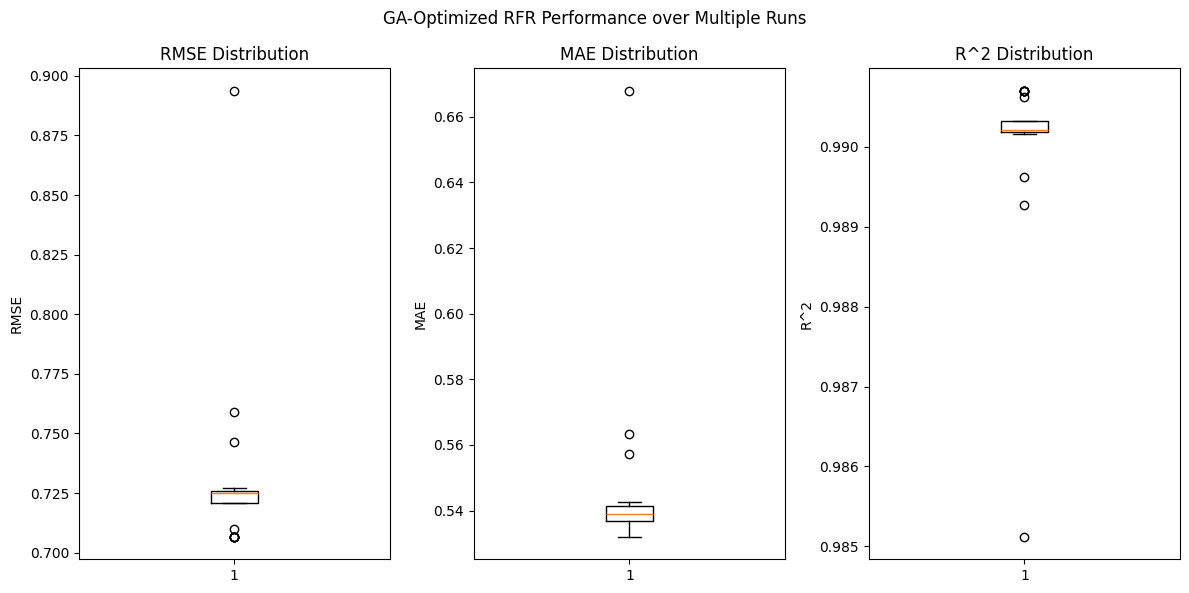

In [15]:
# Run multiple GA optimization runs to finalize hyperparameters
results_df = multiple_ga_runs_rfr(X_train, y_train, runs=30)

In [27]:
# Select best run based on lowest RMSE
best_run = results_df.iloc[results_df['RMSE'].idxmin()]
best_params = {
    'n_estimators': best_run['n_estimators'],
    'max_depth': best_run['max_depth'],
    'min_samples_split': best_run['min_samples_split'],
    'min_samples_leaf': best_run['min_samples_leaf']
}
print(f"Best hyperparameters: {best_params}")

Best hyperparameters: {'n_estimators': np.float64(200.0), 'max_depth': np.float64(20.0), 'min_samples_split': np.float64(2.0), 'min_samples_leaf': np.float64(1.0)}


In [28]:
max_depth_val = best_params['max_depth']
if max_depth_val is not None:
    max_depth_val = int(max_depth_val)

final_rfr_model = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(
        n_estimators=int(best_params['n_estimators']),
        max_depth=max_depth_val,
        min_samples_split=int(best_params['min_samples_split']),
        min_samples_leaf=int(best_params['min_samples_leaf']),
        random_state=42
    )
)
final_rfr_model.fit(X_train, y_train)


,steps,"[('standardscaler', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2


Final GA-Optimized Random Forest RMSE: 1.8521
Final GA-Optimized Random Forest MAE: 1.4391
Final GA-Optimized Random Forest R^2: 0.9512


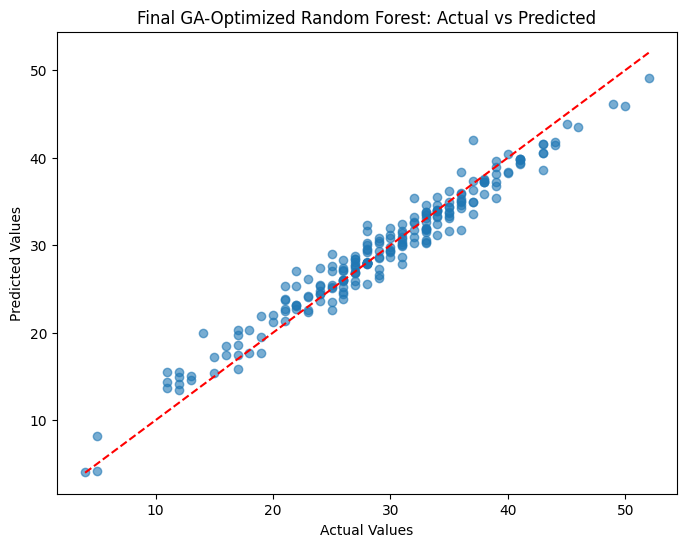

In [32]:
# Evaluate final model on held-out validation set
y_val_pred = final_rfr_model.predict(X_val)

def evaluate_and_plot(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name} RMSE: {rmse:.4f}")
    print(f"{model_name} MAE: {mae:.4f}")
    print(f"{model_name} R^2: {r2:.4f}")
    
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.show()

evaluate_and_plot('Final GA-Optimized Random Forest', y_val, y_val_pred)